In [3]:
import pandas as pd
df=pd.read_csv("tshirt1.csv")
df

,Height,Weight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Height  18 non-null     int64 
 1   Weight  18 non-null     int64 
 2   Size    18 non-null     object
dtypes: int64(2), object(1)
memory usage: 564.0+ bytes


In [12]:
x=df[["Height","Weight"]]
y=df["Size"]
print(x.shape)
print(y.shape)

(18, 2)
(18,)


In [13]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
prediction=model.predict(x)
print(prediction)

['M' 'M' 'M' 'M' 'M' 'M' 'L' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']


In [14]:
diff=pd.DataFrame({'Actual':y,'Predicted':prediction})
diff

,Actual,Predicted
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
5,M,M
6,M,L
7,L,M
8,L,L
9,L,L


In [15]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[10  1]
 [ 1  6]]


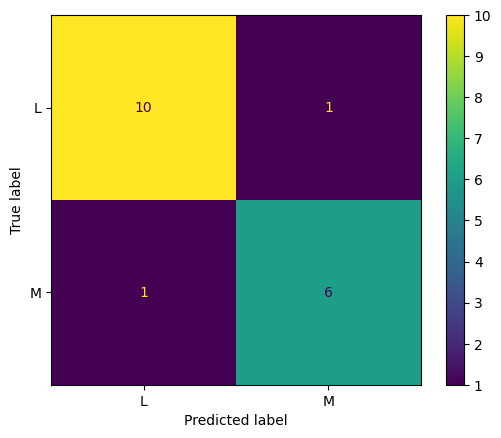

In [16]:
import matplotlib.pyplot as plt
from sklearn import metrics
cm_disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['L','M'])
cm_disp.plot()
plt.show()

In [17]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

10 1 1 6


In [18]:
model_accuracy = (TP+ TN)/(TP+FP+FN+TN)
print("Accuracy score:",model_accuracy)

Accuracy score: 0.8888888888888888


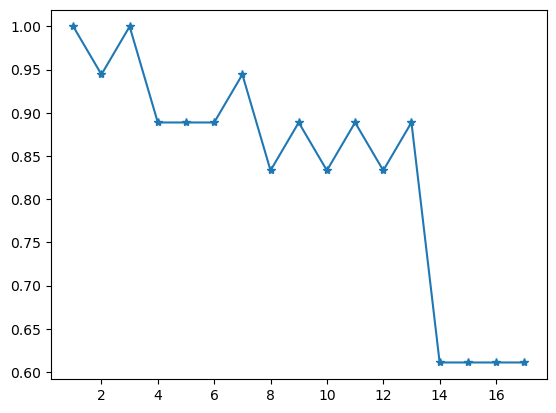

In [21]:
from sklearn.neighbors import KNeighborsClassifier
acc=[]
for i in range(1,18):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x,y)
    predicton=model.predict(x)
    cm= confusion_matrix(y,predicton)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    model_accuracy = (TP+ TN)/(TP+FP+FN+TN)
    acc.append(model_accuracy)
plt.plot(range(1,18),acc,marker="*")
plt.show()

In [22]:
df=pd.read_csv("AptitudeCommunication.csv")
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Speaker
8,Govind,8,3.0,Intel
9,Sushant,6,5.5,Leader


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           14 non-null     object 
 1   Aptitude       14 non-null     int64  
 2   Communication  14 non-null     float64
 3   Class          14 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 580.0+ bytes


In [24]:
x=df[["Aptitude",'Communication']]
y=df["Class"]
print(x.shape)
print(y.shape)

(14, 2)
(14,)


In [26]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
prediction=model.predict(x)
print(prediction)

['Speaker' 'Speaker' 'Leader' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Leader' 'Intel' 'Leader' 'Intel' 'Leader']


In [27]:
diff=pd.DataFrame({'Actual':y,'Predicted':prediction})
diff

,Actual,Predicted
0,Speaker,Speaker
1,Speaker,Speaker
2,Leader,Leader
3,Intel,Intel
4,Leader,Leader
5,Speaker,Speaker
6,Intel,Intel
7,Speaker,Speaker
8,Intel,Intel
9,Leader,Leader


In [28]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[5 0 0]
 [0 5 0]
 [0 0 4]]


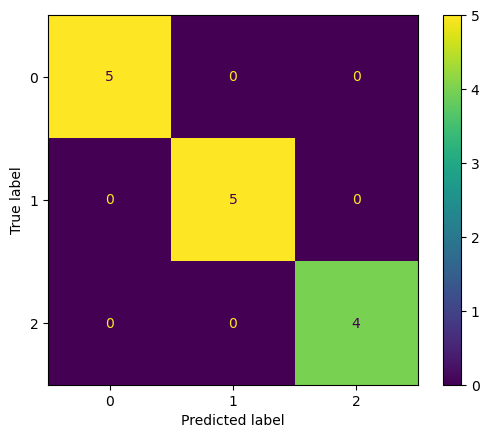

In [29]:
import matplotlib.pyplot as plt
from sklearn import metrics
cm_disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['0','1','2'])
cm_disp.plot()
plt.show()

In [30]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

5 0 0 5


In [31]:
model_accuracy = (TP+ TN)/(TP+FP+FN+TN)
print("Accuracy score:",model_accuracy)

Accuracy score: 1.0


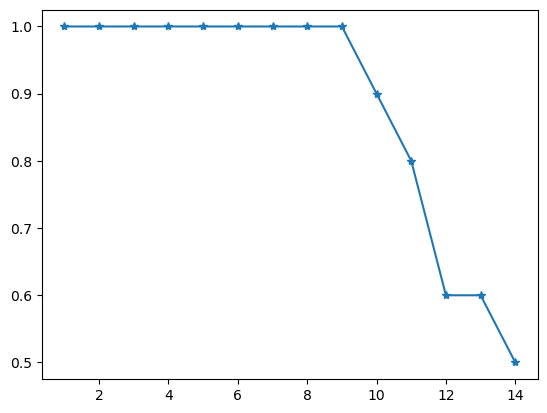

In [34]:
from sklearn.neighbors import KNeighborsClassifier
acc=[]
for i in range(1,15):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x,y)
    predicton=model.predict(x)
    cm= confusion_matrix(y,predicton)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    model_accuracy = (TP+ TN)/(TP+FP+FN+TN)
    acc.append(model_accuracy)
plt.plot(range(1,15),acc,marker="*")
plt.show()

### Decision Tree

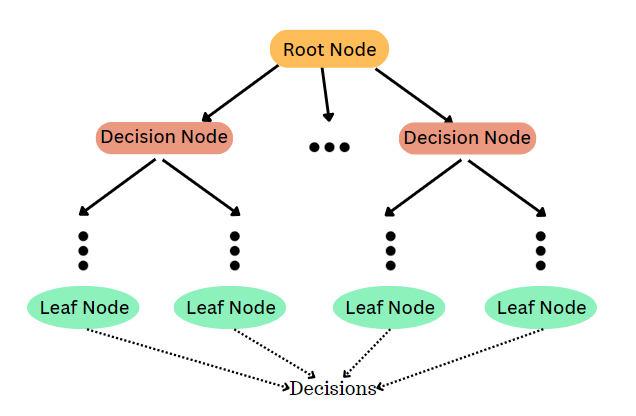

- (5) sunny = {-3,+2} = (-3/5)log2(3/5)- (2/5)log2(2/5) = 0.97
- (4) cloudy = {0,+4} = (-0/4)log2(0/4)- (4/4)log2(4/4) = 0
- (5) rain ={-2,+3} = (-2/5)log2(2/5) - (3/5)log2(3/5) = 0.97
- IG (weather) = 0.94 -(5/14(0.97) + 4/14(0) + 5/14(0.97)) = 0.247
- s(hot) = {-2,+2}=1
- s(mid) = {-2,+4}=0.91
- s(cold) = {-1,+3}=0.87
- IG (Temp) = 0.94 -(4/14(1) + 6/14(0.91) + 4/14(0.81)) = 0.032
- s(high) = {-1,+6} = 0.985
- s(normal) = {-2,+3} = 0.59
- IG (Humidity) = 0.94 -(7/14(0.985) + 7/14(0.59)) = 0.15
- s(weak) ={-2,+6} =0.84
- s(strong) = {-3,+13} = 1
- IG(wind) =0.048

In [40]:
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [42]:
x=df.drop("Job Offered",axis=1)
y=df["Job Offered"]

In [44]:
from sklearn.tree import DecisionTreeClassifier
dtree_entropy= DecisionTreeClassifier(criterion="entropy")
model=dtree_entropy.fit(x,y)
prediction=dtree_entropy.predict(x)
prediction

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [45]:
diff=pd.DataFrame({'Actual':y,'Predicted':prediction})
diff

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1
